# Cluster Validation: Internal and Relative Metrics

## Overview

Clustering is unsupervised — there is no ground truth to compare against in practice. Validation metrics assess cluster quality without labels, using only the data and cluster assignments.

**Three categories:**

| Category | What it measures | When to use |
|---|---|---|
| **Internal** | Compactness and separation using only data | Primary tool; always compute |
| **Relative** | Compare solutions across k or algorithms | Choosing k; comparing methods |
| **External** | Agreement with known labels | When ground truth exists (research/benchmarking) |

**Internal metrics reference:**

| Metric | Formula intuition | Better when | Range |
|---|---|---|---|
| **Silhouette width** | (between − within) / max | Closer to 1 | [−1, 1] |
| **Calinski-Harabasz (CH)** | Between-cluster SS / within-cluster SS | Higher | [0, ∞) |
| **Davies-Bouldin (DB)** | Mean of worst-case cluster similarity ratios | Lower | [0, ∞) |
| **Dunn index** | Min inter-cluster / max intra-cluster distance | Higher | [0, ∞) |

No single metric is universally best — use multiple and look for agreement.

---

## Setup

In [13]:
library(tidyverse)
library(ggplot2)
library(cluster)
library(clusterSim)
library(fpc)
library(factoextra)
library(patchwork)
library(mclust)

set.seed(42)

# ── Simulate data with 3 known clusters ───────────────────────────────────────
n_per <- 80
val_data <- bind_rows(
  tibble(nitrate = rnorm(n_per, 2,   0.6), water_qual = rnorm(n_per, 8,   0.7),
         phosphorus = rnorm(n_per, 0.3, 0.1), turbidity = rnorm(n_per, 3,   0.9),
         true_group = "reference"),
  tibble(nitrate = rnorm(n_per, 5.5, 0.7), water_qual = rnorm(n_per, 5,   0.8),
         phosphorus = rnorm(n_per, 0.8, 0.15), turbidity = rnorm(n_per, 8,  1.2),
         true_group = "restored"),
  tibble(nitrate = rnorm(n_per, 9,   0.9), water_qual = rnorm(n_per, 2.5, 0.8),
         phosphorus = rnorm(n_per, 1.6, 0.25), turbidity = rnorm(n_per, 16, 2),
         true_group = "degraded")
)

# dplyr::select() to avoid masking; as.matrix() for scale(); storage.mode() for safety
X_raw <- dplyr::select(val_data, nitrate, water_qual, phosphorus, turbidity)
X     <- as.matrix(X_raw)
storage.mode(X) <- "numeric"
X_sc  <- scale(X)
d_mat <- dist(X_sc)

# purrr::map() explicit to avoid fpc/clusterSim masking map()
# lapply also works as a fallback
km_list <- lapply(2:8, function(k) kmeans(X_sc, centers = k, nstart = 25, iter.max = 100))

---

## Silhouette Width

Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <https://github.com/kassambara/factoextra/issues>."


  cluster size ave.sil.width
1       1   80          0.64
2       2   80          0.75
3       3   80          0.67


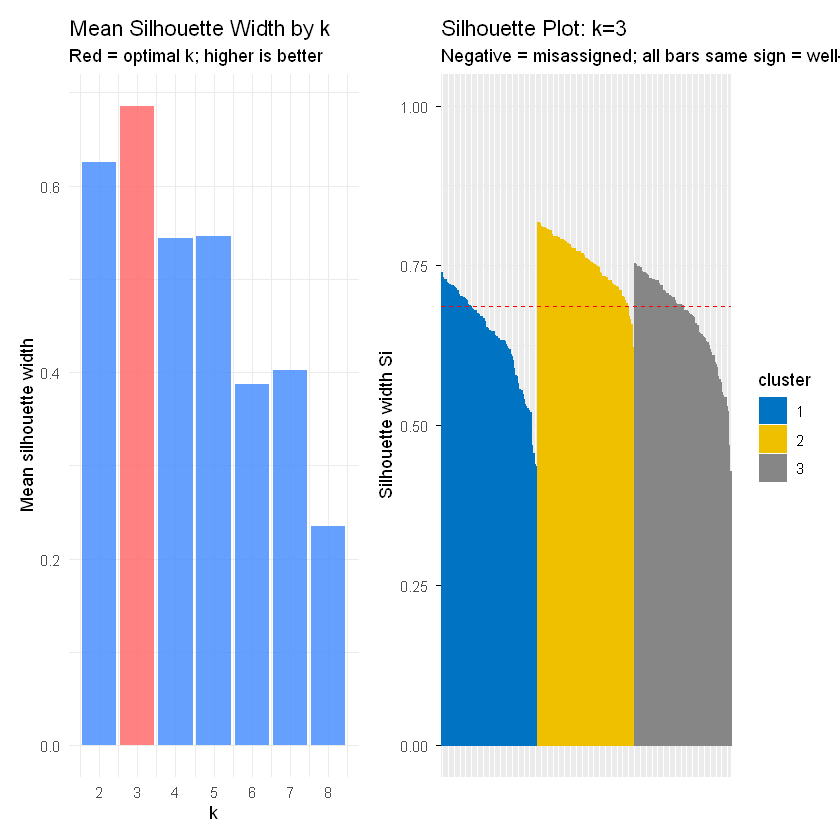

In [14]:
# Silhouette width for observation i:
# s(i) = (b(i) - a(i)) / max(a(i), b(i))
# a(i) = mean distance to observations in same cluster (compactness)
# b(i) = mean distance to observations in nearest other cluster (separation)

sil_scores <- map_dbl(km_list, function(km) {
  mean(cluster::silhouette(km$cluster, d_mat)[, 3])
})

# Per-observation silhouette for k=3
km3  <- km_list[[2]]   # k=3 is index 2 (k=2..8)
sil3 <- cluster::silhouette(km3$cluster, d_mat)

p_sil_bar <- tibble(k=2:8, silhouette=sil_scores) %>%
  ggplot(aes(x=k, y=silhouette, fill=silhouette==max(silhouette))) +
  geom_col(alpha=0.85) +
  scale_fill_manual(values=c("FALSE"="#4a8fff","TRUE"="#ff6b6b"), guide="none") +
  scale_x_continuous(breaks=2:8) +
  labs(title="Mean Silhouette Width by k",
       subtitle="Red = optimal k; higher is better",
       x="k", y="Mean silhouette width") +
  theme_minimal()

p_sil_plot <- factoextra::fviz_silhouette(sil3, palette="jco",
                                           ggtheme=theme_minimal()) +
  labs(title="Silhouette Plot: k=3",
       subtitle="Negative = misassigned; all bars same sign = well-separated clusters")

(p_sil_bar | p_sil_plot)

---

## Calinski-Harabasz and Davies-Bouldin Indices

# A tibble: 7 × 6
      k silhouette calinski_harabasz   dunn within_ss davies_bouldin
  <dbl>      <dbl>             <dbl>  <dbl>     <dbl>          <dbl>
1     2      0.626              619. 0.329      266.           0.529
2     3      0.686             1321. 0.423       78.7          0.477
3     4      0.544             1015. 0.109       68.8          1.12 
4     5      0.546              842. 0.082       62.4          1.05 
5     6      0.387              742. 0.043       56.7          1.38 
6     7      0.403              671. 0.0744      52.3          1.29 
7     8      0.236              620. 0.0565      48.5          1.46 


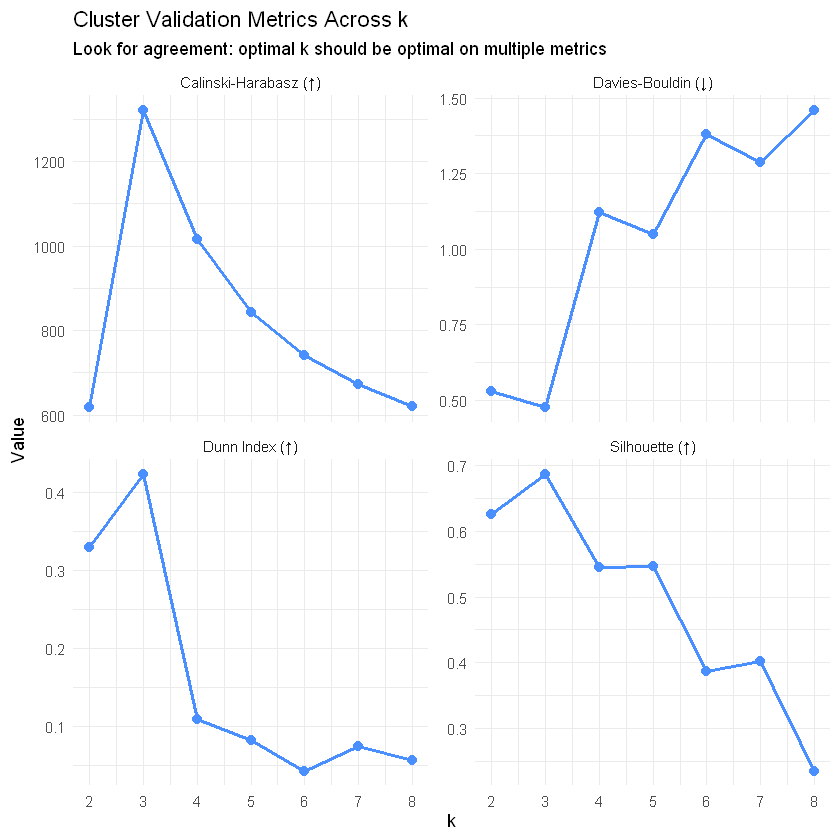

In [16]:
# ── All metrics across k using fpc::cluster.stats() ──────────────────────────
metrics_df <- do.call(rbind, lapply(km_list, function(km) {
  cs <- fpc::cluster.stats(d_mat, km$cluster)
  tibble(
    k                 = max(km$cluster),
    silhouette        = cs$avg.silwidth,
    calinski_harabasz = cs$ch,
    dunn              = cs$dunn,
    within_ss         = cs$within.cluster.ss
  )
}))

# Davies-Bouldin: mean of max within/between ratio; lower = better
metrics_df$davies_bouldin <- sapply(km_list, function(km) {
  clusterSim::index.DB(X_sc, km$cluster)$DB
})

print(metrics_df %>% dplyr::mutate(dplyr::across(where(is.numeric), ~round(.x, 4))))

# ── Plot all metrics ──────────────────────────────────────────────────────────
metrics_long <- metrics_df %>%
  dplyr::select(k, silhouette, calinski_harabasz, davies_bouldin, dunn) %>%
  tidyr::pivot_longer(-k, names_to = "metric", values_to = "value") %>%
  dplyr::mutate(better = dplyr::case_when(
    metric %in% c("silhouette", "calinski_harabasz", "dunn") ~ "higher",
    metric == "davies_bouldin" ~ "lower"
  ))

ggplot(metrics_long, aes(x = k, y = value)) +
  geom_line(color = "#4a8fff", linewidth = 1) +
  geom_point(size = 2.5, color = "#4a8fff") +
  facet_wrap(~metric, scales = "free_y", ncol = 2,
             labeller = labeller(metric = c(
               silhouette        = "Silhouette (↑)",
               calinski_harabasz = "Calinski-Harabasz (↑)",
               davies_bouldin    = "Davies-Bouldin (↓)",
               dunn              = "Dunn Index (↑)"
             ))) +
  scale_x_continuous(breaks = 2:8) +
  labs(title    = "Cluster Validation Metrics Across k",
       subtitle = "Look for agreement: optimal k should be optimal on multiple metrics",
       x = "k", y = "Value") +
  theme_minimal()

---

## External Validation: When Ground Truth Exists

In [17]:
# External metrics compare cluster assignments to known labels
# Only valid in research/benchmarking contexts — not available in practice

true_labels <- as.integer(factor(val_data$true_group))

ext_metrics <- map_dfr(km_list, function(km) {
  cs <- fpc::cluster.stats(d_mat, km$cluster, alt.clustering=true_labels)
  tibble(
    k   = max(km$cluster),
    ari = mclust::adjustedRandIndex(km$cluster, true_labels),  # [-1,1]; 1=perfect
    vi  = cs$vi   # variation of information; lower = better
  )
})

print(ext_metrics %>% mutate(across(where(is.numeric), ~round(.x, 4))))

# ARI interpretation:
# 1.0 = perfect agreement with true labels
# 0.0 = no better than random assignment
# Negative = worse than random (unusual; usually a sign of k mismatch)

# Contingency table for k=3
cat("\nContingency table (k=3 vs. true groups):\n")
print(table(cluster=km3$cluster, true_group=val_data$true_group))

# A tibble: 7 × 3
      k   ari    vi
  <dbl> <dbl> <dbl>
1     2 0.569 0.462
2     3 1     0    
3     4 0.869 0.230
4     5 0.828 0.356
5     6 0.676 0.592
6     7 0.635 0.710
7     8 0.464 0.946

Contingency table (k=3 vs. true groups):
       true_group
cluster degraded reference restored
      1       80         0        0
      2        0        80        0
      3        0         0       80


---

## Common Pitfalls

**1. Using a single validation metric to choose k**  
Each metric captures a different aspect of cluster quality and can disagree. Silhouette favours compact, well-separated clusters; CH can be biased toward larger k; DB can be fooled by non-convex shapes. Always compute at least three metrics and require agreement before concluding on k.

**2. Applying internal validation metrics without understanding their assumptions**  
All three primary metrics (silhouette, CH, DB) assume clusters are convex and relatively compact. They will systematically underperform for DBSCAN results on irregular shapes, or for GMM components with very different orientations. The metric and the clustering algorithm should be aligned in their geometric assumptions.

**3. Conflating high silhouette with meaningful clusters**  
A solution with silhouette = 0.75 indicates that the clusters are well-separated *relative to each other*, not that the clusters correspond to real-world groupings. Always validate cluster interpretability with domain knowledge and descriptive profiling — see `cluster_profiling.ipynb`.

**4. Using external validation as the primary criterion in exploratory clustering**  
If known labels exist and you optimise k to maximise ARI against them, you are doing supervised classification, not unsupervised clustering. External validation is legitimate for benchmarking algorithms but not for choosing the final k in applied work.

**5. Not checking whether the "best" k is sensitive to small changes in the data**  
Stability analysis — rerunning clustering on bootstrap subsamples and measuring ARI between solutions — is a valuable complement to metric-based selection. If the optimal k changes frequently across subsamples, the cluster structure is unstable and may not be reliable.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*